<a href="https://colab.research.google.com/github/gunaanand08/Ioe/blob/main/experiment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original Dataset
   Temperature  Humidity  Pressure  Gas  Light
0         28.5        64    1012.4  215    325
1         28.7        65    1012.6  218    340
2         28.4        64    1012.5  220    355
3         28.9        66    1012.8  217    370
4         29.2        67    1013.0  223    390

Normalized Dataset
   Temperature  Humidity  Pressure       Gas     Light
0     0.047619  0.444444  0.266667  0.047619  0.109890
1     0.142857  0.555556  0.400000  0.119048  0.142857
2     0.000000  0.444444  0.333333  0.166667  0.175824
3     0.238095  0.666667  0.533333  0.095238  0.208791
4     0.380952  0.777778  0.666667  0.238095  0.252747


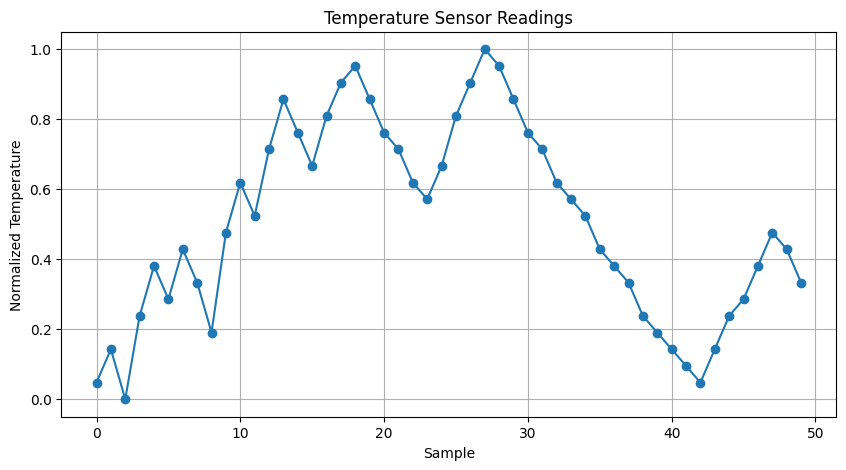

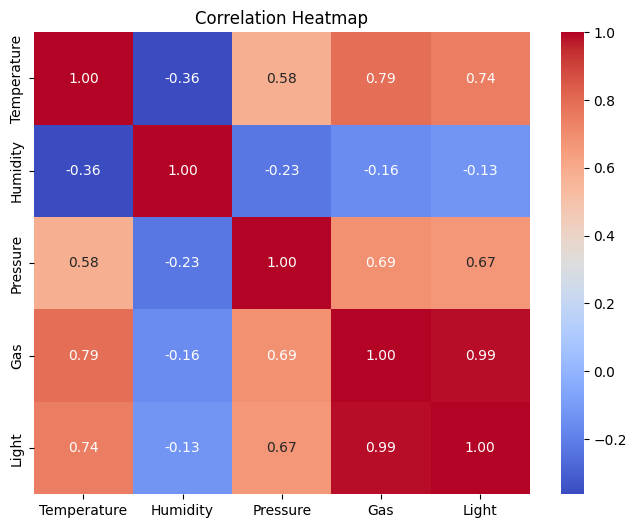

In [ ]:
# ==========================
# Import Libraries
# ==========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# ==========================
# Create Realistic Sensor Dataset
# ==========================

data = {
    "Temperature": [
        28.5, 28.7, 28.4, 28.9, 29.2, 29.0, 29.3, 29.1, 28.8, 29.4,
        29.7, 29.5, 29.9, 30.2, 30.0, 29.8, 30.1, 30.3, 30.4, 30.2,
        30.0, 29.9, 29.7, 29.6, 29.8, 30.1, 30.3, 30.5, 30.4, 30.2,
        30.0, 29.9, 29.7, 29.6, 29.5, 29.3, 29.2, 29.1, 28.9, 28.8,
        28.7, 28.6, 28.5, 28.7, 28.9, 29.0, 29.2, 29.4, 29.3, 29.1
    ],

    "Humidity": [
        64,65,64,66,67,66,68,67,66,65,
        64,63,62,61,60,61,62,63,64,65,
        66,67,68,69,68,67,66,65,64,63,
        62,61,60,61,62,63,64,65,66,67,
        68,69,68,67,66,65,64,63,62,61
    ],

    "Pressure": [
        1012.4,1012.6,1012.5,1012.8,1013.0,1012.9,1013.1,1013.3,1013.2,1013.0,
        1012.9,1012.8,1012.7,1012.9,1013.1,1013.2,1013.4,1013.5,1013.3,1013.2,
        1013.0,1012.9,1012.8,1012.7,1012.6,1012.8,1013.0,1013.2,1013.3,1013.1,
        1012.9,1012.8,1012.7,1012.6,1012.5,1012.4,1012.3,1012.2,1012.1,1012.0,
        1012.2,1012.4,1012.5,1012.7,1012.9,1013.0,1013.1,1013.2,1013.0,1012.8
    ],

    "Gas": [
        215,218,220,217,223,226,228,230,229,231,
        235,238,240,242,245,247,250,252,255,253,
        250,248,245,243,240,238,236,235,233,231,
        229,227,225,223,221,220,218,216,214,213,
        215,217,219,221,223,225,227,229,228,226
    ],

    "Light": [
        325,340,355,370,390,420,450,480,510,540,
        570,600,630,650,670,690,710,720,730,725,
        710,690,670,640,610,580,550,520,490,460,
        430,400,380,360,340,320,300,290,280,275,
        285,295,310,330,360,390,420,450,430,410
    ]
}

df = pd.DataFrame(data)

print("Original Dataset")
print(df.head())

# ==========================
# Data Cleaning
# ==========================

df.fillna(df.mean(numeric_only=True), inplace=True)
df.drop_duplicates(inplace=True)

# ==========================
# Normalize Data
# ==========================

scaler = MinMaxScaler()
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = scaler.fit_transform(df[num_cols])

print("\nNormalized Dataset")
print(df.head())

# Save dataset
df.to_csv("clean_sensor_data.csv", index=False)

# ==========================
# Temperature Plot
# ==========================

plt.figure(figsize=(10,5))
plt.plot(df["Temperature"], marker='o')
plt.title("Temperature Sensor Readings")
plt.xlabel("Sample")
plt.ylabel("Normalized Temperature")
plt.grid(True)
plt.show()

# ==========================
# Correlation Heatmap
# ==========================

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()